***
# Mapping Wildfires
#### by Paul Ghisletti, as part of the SDS210 course (spring semester '26)

***

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import requests

***
## API
Make sure you followed the steps 2.1. to 2.3. in the `README.md` file on how to set your individual API-key: Check, whether the following output matches your individual API-key from FIRMS. Here, you can also see how many free transactions you have left with your api-key

In [14]:
load_dotenv()

api_key = os.getenv("MY_API_KEY")
print(f"API-Key: {api_key}")

url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + api_key
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  # possible error, wrong MAP_KEY value, check for extra quotes, missing letters
  print ("There is an issue with the query. \nTry in your browser: %s" % url)

API-Key: 3d1ef73c3c932e5f3738d87f205a9cec


transaction_limit             5000
current_transactions            72
transaction_interval    10 minutes
dtype: object

We can also define a function which tells us how many transactions we have used so far. This can be used to check, how many transactions one API query costs (code from the [FIRMS notebook on *API use*](https://firms.modaps.eosdis.nasa.gov/academy/data_api/)):

In [15]:
def get_transaction_count() :
  count = 0
  try:
    response = requests.get(url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print ('Our current transaction count is %i' % tcount)

Our current transaction count is 72


***
## 1. Loading a dataset through the API

In [16]:
# in this example let's look at VIIRS NOAA-20, entire world and the most recent day
area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + api_key + '/VIIRS_NOAA20_NRT/world/1'
start_count = get_transaction_count()
df_area = pd.read_csv(area_url)
end_count = get_transaction_count()
print ('This query used %i transactions.' % (end_count-start_count))

df_area

This query used 36 transactions.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,66.13667,57.34295,328.85,0.33,0.55,2026-05-05,35,N20,VIIRS,n,2.0NRT,270.08,1.27,D
1,65.56367,22.21828,331.78,0.51,0.41,2026-05-05,37,N20,VIIRS,n,2.0NRT,275.04,4.92,N
2,53.46284,41.65497,305.59,0.44,0.62,2026-05-05,39,N20,VIIRS,n,2.0NRT,280.82,1.25,N
3,53.93356,38.97771,305.16,0.34,0.56,2026-05-05,39,N20,VIIRS,n,2.0NRT,278.89,0.53,N
4,54.21367,38.92506,313.06,0.33,0.55,2026-05-05,39,N20,VIIRS,n,2.0NRT,286.20,1.25,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12448,52.90208,-115.32400,335.63,0.40,0.40,2026-05-05,2039,N20,VIIRS,n,2.1URT,293.32,3.57,D
12449,53.38910,-106.10876,330.44,0.30,0.50,2026-05-05,2039,N20,VIIRS,n,2.1URT,285.56,1.34,D
12450,54.22145,-109.64229,340.72,0.50,0.50,2026-05-05,2040,N20,VIIRS,n,2.1URT,288.89,4.91,D
12451,54.22585,-109.64307,332.42,0.50,0.50,2026-05-05,2040,N20,VIIRS,n,2.1URT,288.54,7.45,D


We can see that there is a longitude and latitude column in the csv file which we imported as a pandas data frame. We can use these two columns to convert it to a geopandas geo data frame, which contains geospatial information (point geometries in this case):

In [17]:
# now convert latitude, longitude values into point geometry

gdf = gpd.GeoDataFrame(
    df_area, geometry=gpd.points_from_xy(df_area.longitude, df_area.latitude), crs="EPSG:4326"
)

# show top 3 records
gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,66.13667,57.34295,328.85,0.33,0.55,2026-05-05,35,N20,VIIRS,n,2.0NRT,270.08,1.27,D,POINT (57.34295 66.13667)
1,65.56367,22.21828,331.78,0.51,0.41,2026-05-05,37,N20,VIIRS,n,2.0NRT,275.04,4.92,N,POINT (22.21828 65.56367)
2,53.46284,41.65497,305.59,0.44,0.62,2026-05-05,39,N20,VIIRS,n,2.0NRT,280.82,1.25,N,POINT (41.65497 53.46284)


Having transformed our data frame to a geospatial data frame, we can now use geopandas built-in `.plot()` method to plot all wildfires from the most recent day available worldwide:

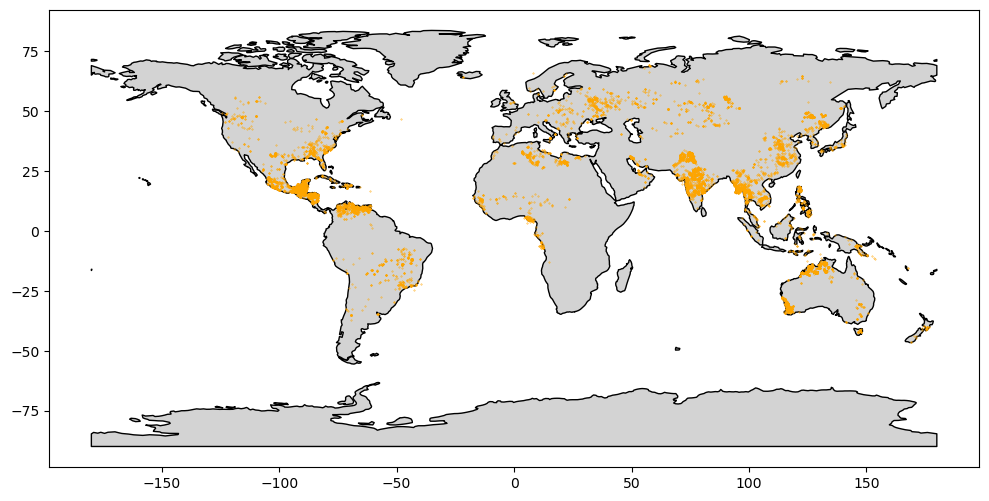

In [18]:
# We first need to import a file with global boundary geometries
path = "/Users/paulghisletti/Desktop/SDS210/wildfires/SDS210-wildifres-project/data/raw/ne_110m_land/ne_110m_land.shp"
world = gpd.read_file(path)

fig, ax = plt.subplots(figsize=(12,7))

world.plot(ax=ax,
           color="lightgrey",
           edgecolor="black")

gdf.plot(ax=ax,
         color="orange",
         markersize=0.1
         )

plt.show()